# Two coupled antimony donor simulation

This notebook is a tutorial for the `Sb2.py` module.  The simulated system is one electron spin coupled to two `123Sb` nuclear spins in silicon:

$$\mathcal{H}=\mathcal{H}_e\otimes\mathcal{H}_{Sb_i}\otimes\mathcal{H}_{Sb_x},\qquad \dim(\mathcal{H})=2\times8\times8=128.$$

The model follows the high-spin donor Hamiltonian used for single antimony donors and extends it to two nuclei:

$$H=\gamma_e B_0 S_z-\gamma_{n,i}B_0 I_{i,z}-\gamma_{n,x}B_0 I_{x,z}+A_i\mathbf{S}\cdot\mathbf{I}_i+A_x\mathbf{S}\cdot\mathbf{I}_x+H_{Q,i}+H_{Q,x}+H_{i,x}.$$

`Sb2.py` also contains ideal unitary operations used in the nuclear-spin qudit literature: global SU(2) rotations, site-local SU(2) rotations, two-level Givens rotations, and SNAP phase gates.

## 1. Imports and basis convention

The tensor order is fixed as `electron x Sb_i x Sb_x`.  The full-space operators are:

- Electron: `Sx`, `Sy`, `Sz`
- First antimony nucleus: `Iix`, `Iiy`, `Iiz`
- Second antimony nucleus: `Ixi`, `Iyi`, `Izi`

The nuclear basis is ordered by QuTiP angular momentum convention: `m_I = +7/2, +5/2, ..., -7/2`.

In [1]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

import Sb2

# Reload while editing Sb2.py from the same notebook session.
Sb2 = importlib.reload(Sb2)

print(f"Full Hilbert-space dimension: {Sb2.DIM_FULL}")
print(f"Nuclear m_I basis: {Sb2.mI_values}")
print(f"Sx shape: {Sb2.Sx.shape}")
print(f"Iiz shape: {Sb2.Iiz.shape}")
print(f"Izi shape: {Sb2.Izi.shape}")

Full Hilbert-space dimension: 128
Nuclear m_I basis: [ 3.5  2.5  1.5  0.5 -0.5 -1.5 -2.5 -3.5]
Sx shape: (128, 128)
Iiz shape: (128, 128)
Izi shape: (128, 128)


## 2. Build a two-antimony Hamiltonian

The two nuclei are allowed to have different hyperfine couplings and quadrupole splittings.  That is the simplest way to represent two physical antimony atoms at different electron-density and strain environments.  The optional `J_zz` term is a small secular nuclear-nuclear coupling.

In [2]:
params = Sb2.Sb2Parameters(
    B=1.38,              # tesla
    A_i=101.52e-3,       # 101.52 MHz in GHz
    A_x=74.0e-3,         # second donor has weaker electron overlap
    fq_i=-44.1e-6,       # -44.1 kHz in GHz
    fq_x=-31.0e-6,       # different local EFG for the second donor
    J_zz=0.25e-6,        # 0.25 kHz secular coupling
)

H = Sb2.H_from_params(params)

print(f"H shape: {H.shape}")
print(f"H is Hermitian: {H.isherm}")
print(f"Lowest 8 energies relative to ground (MHz):")
print(np.round(Sb2.eigenenergies(H)[:8] * 1e3, 6))

H shape: (128, 128)
H is Hermitian: True
Lowest 8 energies relative to ground (MHz):
[  0.        44.663659  58.363559  89.337084 103.026421 116.7671
 134.0207   147.698545]


## 3. Inspect the Hamiltonian terms

The electron Zeeman term is by far the largest scale.  The hyperfine terms split the nuclear transitions by tens of MHz depending on the electron spin.  The quadrupole and explicit nuclear-nuclear coupling terms are much smaller but break degeneracies and make adjacent transitions non-uniform.

In [3]:
terms = {
    "electron Zeeman": Sb2.H_electron_zeeman(B=params.B, ge=params.gamma_electron),
    "nuclear Zeeman": Sb2.H_nuclear_zeeman(B=params.B, gn_i=params.gamma_n_i, gn_x=params.gamma_n_x),
    "hyperfine": Sb2.H_hyperfine(A_i=params.A_i, A_x=params.A_x),
    "quadrupole": Sb2.H_quadrupole(fq_i=params.fq_i, fq_x=params.fq_x),
    "nuclear-nuclear": Sb2.H_nuclear_nuclear(J_zz=params.J_zz),
}

for name, term in terms.items():
    # Spectral width is a useful scale estimate for a Hamiltonian term.
    ev = term.eigenenergies()
    print(f"{name:16s}: width = {(ev[-1] - ev[0]) * 1e3:10.6f} MHz")

electron Zeeman : width = 38598.600000 MHz
nuclear Zeeman  : width = 107.283960 MHz
hyperfine       : width = 659.353609 MHz
quadrupole      : width =   0.901200 MHz
nuclear-nuclear : width =   0.006125 MHz


## 4. Product-basis NMR transition frequencies

In the high-field limit, the eigenstates are close to `|m_s, m_i, m_x>` product states.  The helper below estimates adjacent `Delta m_I = 1` transition frequencies by taking expectation values in those product states.  This is fast and useful for intuition before doing full diagonalization or driven dynamics.

In [4]:
Sb2.print_adjacent_nmr_frequencies(H, site="i", electron="down", other_m=-7/2, unit="MHz")
print()
Sb2.print_adjacent_nmr_frequencies(H, site="x", electron="down", other_m=-7/2, unit="MHz")
print()
Sb2.print_adjacent_nmr_frequencies(H, site="i", electron="up", other_m=-7/2, unit="MHz")

Adjacent NMR transitions for Sb_i with electron=down:
  +3.5 <-> +2.5: 58.688615 MHz
  +2.5 <-> +1.5: 58.600415 MHz
  +1.5 <-> +0.5: 58.512215 MHz
  +0.5 <-> -0.5: 58.424015 MHz
  -0.5 <-> -1.5: 58.335815 MHz
  -1.5 <-> -2.5: 58.247615 MHz
  -2.5 <-> -3.5: 58.159415 MHz

Adjacent NMR transitions for Sb_x with electron=down:
  +3.5 <-> +2.5: 44.850015 MHz
  +2.5 <-> +1.5: 44.788015 MHz
  +1.5 <-> +0.5: 44.726015 MHz
  +0.5 <-> -0.5: 44.664015 MHz
  -0.5 <-> -1.5: 44.602015 MHz
  -1.5 <-> -2.5: 44.540015 MHz
  -2.5 <-> -3.5: 44.478015 MHz

Adjacent NMR transitions for Sb_i with electron=up:
  +3.5 <-> +2.5: 42.831385 MHz
  +2.5 <-> +1.5: 42.919585 MHz
  +1.5 <-> +0.5: 43.007785 MHz
  +0.5 <-> -0.5: 43.095985 MHz
  -0.5 <-> -1.5: 43.184185 MHz
  -1.5 <-> -2.5: 43.272385 MHz
  -2.5 <-> -3.5: 43.360585 MHz


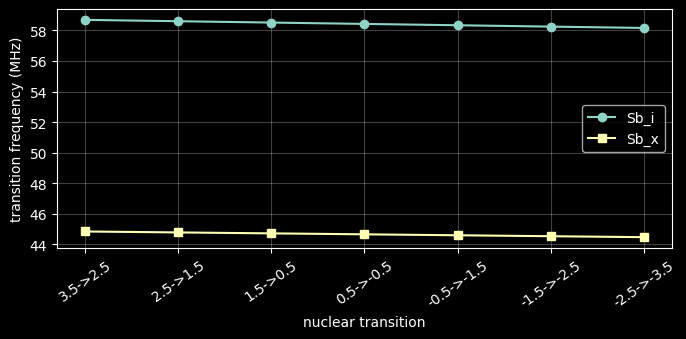

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))

for site, marker in [("i", "o"), ("x", "s")]:
    rows = Sb2.adjacent_nmr_frequencies(H, site=site, electron="down", other_m=-7/2)
    labels = [f"{a:g}->{b:g}" for a, b, _ in rows]
    freqs_mhz = [f * 1e3 for _, _, f in rows]
    ax.plot(labels, freqs_mhz, marker=marker, lw=1.5, label=f"Sb_{site}")

ax.set_ylabel("transition frequency (MHz)")
ax.set_xlabel("nuclear transition")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=35)
plt.tight_layout()

## 5. Sweep the second hyperfine coupling

This sweep mimics moving the electron wavefunction between the two donor sites or fitting a device where the electron has unequal density at the two nuclei.  Only the low-energy manifold is plotted here so the structure is visible.

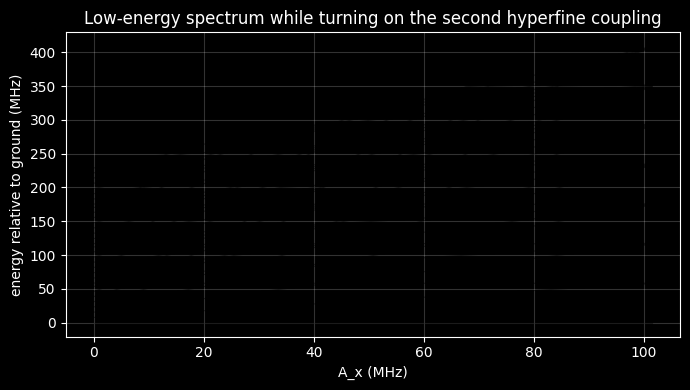

In [6]:
A_x_values = np.linspace(0.0, params.A_i, 25)
spectra_mhz = []

for A_x in A_x_values:
    H_sweep = Sb2.H_total(
        B=params.B,
        A_i=params.A_i,
        A_x=A_x,
        fq_i=params.fq_i,
        fq_x=params.fq_x,
        J_zz=params.J_zz,
    )
    spectra_mhz.append(Sb2.eigenenergies(H_sweep)[:32] * 1e3)

spectra_mhz = np.array(spectra_mhz)

fig, ax = plt.subplots(figsize=(7, 4))
for level in range(spectra_mhz.shape[1]):
    ax.plot(A_x_values * 1e3, spectra_mhz[:, level], color="black", lw=0.8, alpha=0.45)

ax.set_xlabel("A_x (MHz)")
ax.set_ylabel("energy relative to ground (MHz)")
ax.set_title("Low-energy spectrum while turning on the second hyperfine coupling")
ax.grid(alpha=0.2)
plt.tight_layout()

## 6. Global and local SU(2) rotations

The cat-state paper emphasizes global SU(2) rotations in the spin-7/2 qudit.  `Sb2.py` has both local rotations on one nucleus and global rotations acting on both nuclei.  The example below starts from `|down, -7/2, -7/2>` and applies a global `pi/2` rotation about `x`.

Local rotation only changes Sb_i:
  <Iiz> = -8.430756093247282e-16
  <Izi> = -3.4999999999999973


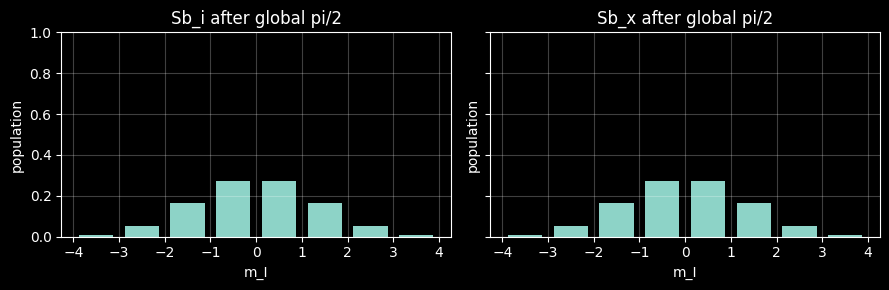

In [7]:
psi0 = Sb2.product_state(electron="down", m_i=-7/2, m_x=-7/2)

U_global = Sb2.global_covariant_su2_rotation(theta=np.pi / 2, phi=0.0)
psi_global = U_global * psi0

U_local = Sb2.nuclear_rotation(site="i", angle=np.pi / 2, axis="x")
psi_local = U_local * psi0

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
axes[0].bar(Sb2.mI_values, Sb2.nuclear_populations(psi_global, "i"), width=0.75)
axes[0].set_title("Sb_i after global pi/2")
axes[1].bar(Sb2.mI_values, Sb2.nuclear_populations(psi_global, "x"), width=0.75)
axes[1].set_title("Sb_x after global pi/2")

for ax in axes:
    ax.set_xlabel("m_I")
    ax.set_ylabel("population")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)

plt.tight_layout()

print("Local rotation only changes Sb_i:")
print("  <Iiz> =", Sb2.iz_expectation(psi_local, "i"))
print("  <Izi> =", Sb2.iz_expectation(psi_local, "x"))

## 7. SNAP phase gates and one-axis twisting

A SNAP gate is diagonal in the `|m_I>` basis and applies programmable phases to each nuclear level.  In a generalized rotating frame this can be implemented virtually by redefining oscillator phases.  The `one_axis_twist` helper is a SNAP phase pattern proportional to `m_I^2`.

Parity before SNAP, Sb_i: -0.000000
Parity after SNAP,  Sb_i: -0.000000
Parity after twist, Sb_i: -0.000000


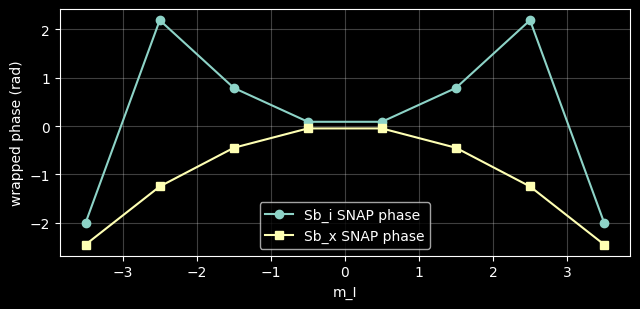

In [8]:
phases_i = 0.35 * Sb2.mI_values**2
phases_x = -0.20 * Sb2.mI_values**2

U_snap = Sb2.two_nucleus_snap(phases_i=phases_i, phases_x=phases_x)
psi_snap = U_snap * psi_global

U_twist_i = Sb2.one_axis_twist(site="i", chi=np.pi / 7)
psi_twist = U_twist_i * psi_global

print(f"Parity before SNAP, Sb_i: {Sb2.parity_expectation(psi_global, 'i'):+.6f}")
print(f"Parity after SNAP,  Sb_i: {Sb2.parity_expectation(psi_snap, 'i'):+.6f}")
print(f"Parity after twist, Sb_i: {Sb2.parity_expectation(psi_twist, 'i'):+.6f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(Sb2.mI_values, np.angle(np.exp(1j * phases_i)), "o-", label="Sb_i SNAP phase")
ax.plot(Sb2.mI_values, np.angle(np.exp(1j * phases_x)), "s-", label="Sb_x SNAP phase")
ax.set_xlabel("m_I")
ax.set_ylabel("wrapped phase (rad)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## 8. Ideal nuclear cat states

`Sb2.py` includes ideal state constructors, which are useful targets for pulse design.  This example embeds an extreme spin-cat state on `Sb_i` while leaving `Sb_x` polarized.

Sb_i populations for ideal |+7/2> + i|-7/2> cat:
[0.5 0.  0.  0.  0.  0.  0.  0.5]
Sb_x remains polarized:
[0. 0. 0. 0. 0. 0. 0. 1.]
Sb_i parity: +0.000000


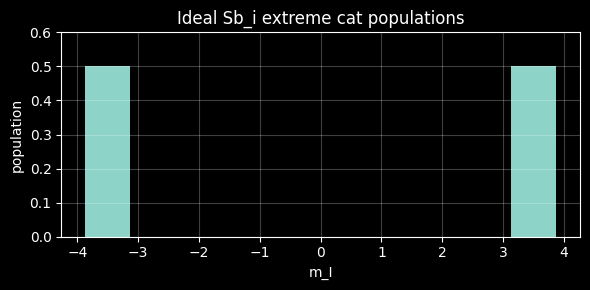

In [9]:
cat_i = Sb2.naked_nuclear_cat_state(m_abs=7/2, phase=np.pi / 2)
psi_cat = Sb2.embed_nuclear_state(site="i", psi_nuclear=cat_i, electron="down", other_m=-7/2)

print("Sb_i populations for ideal |+7/2> + i|-7/2> cat:")
print(np.round(Sb2.nuclear_populations(psi_cat, "i"), 6))
print("Sb_x remains polarized:")
print(np.round(Sb2.nuclear_populations(psi_cat, "x"), 6))
print(f"Sb_i parity: {Sb2.parity_expectation(psi_cat, 'i'):+.6f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(Sb2.mI_values, Sb2.nuclear_populations(psi_cat, "i"), width=0.75)
ax.set_xlabel("m_I")
ax.set_ylabel("population")
ax.set_title("Ideal Sb_i extreme cat populations")
ax.set_ylim(0, 0.6)
ax.grid(alpha=0.25)
plt.tight_layout()

## 9. Time evolution under the static Hamiltonian

`Sb2.evolve_state` accepts Hamiltonians in GHz and times in ns.  It internally multiplies the Hamiltonian by `2*pi` so QuTiP receives angular frequencies.  The example below follows a globally rotated state under the full static Hamiltonian and tracks `Iz` on both nuclei.

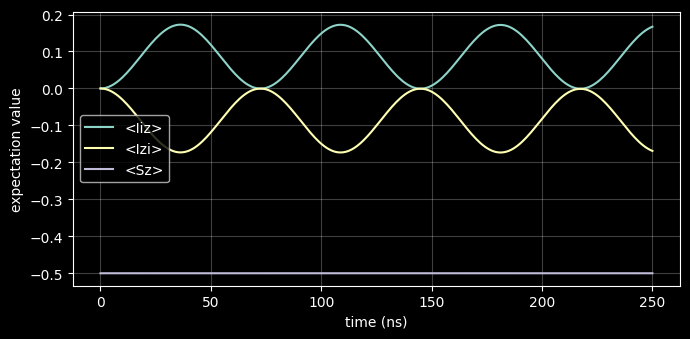

In [10]:
times_ns = np.linspace(0, 250, 251)

result = Sb2.evolve_state(
    H,
    psi_global,
    times_ns,
    e_ops=[Sb2.Iiz, Sb2.Izi, Sb2.Sz],
    options={"store_states": True},
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(times_ns, result.expect[0], label="<Iiz>")
ax.plot(times_ns, result.expect[1], label="<Izi>")
ax.plot(times_ns, result.expect[2], label="<Sz>")
ax.set_xlabel("time (ns)")
ax.set_ylabel("expectation value")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## 10. A simple conditional phase from the explicit nuclear-nuclear term

The optional `J_zz Iiz Izi` term creates phases that depend on both nuclear spin projections.  The next cell exaggerates `J_zz` so the effect is visible in a short simulated time.  Use experimentally justified values for quantitative work.

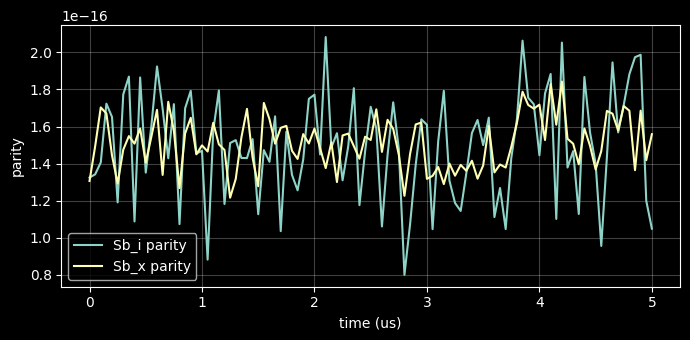

In [11]:
H_coupling_only = Sb2.H_nuclear_nuclear(J_zz=20e-6)  # 20 kHz, exaggerated for visibility

psi_i_plus = Sb2.naked_spin_coherent_state(theta=np.pi / 2, phi=0.0, reference_m=-7/2)
psi_x_plus = Sb2.naked_spin_coherent_state(theta=np.pi / 2, phi=0.0, reference_m=-7/2)
psi_plus_plus = Sb2.two_nucleus_product(psi_i_plus, psi_x_plus, electron="down")

coupling_times_ns = np.linspace(0, 5_000, 101)
coupling_result = Sb2.evolve_state(
    H_coupling_only,
    psi_plus_plus,
    coupling_times_ns,
    e_ops=[Sb2.parity_operator("i"), Sb2.parity_operator("x")],
    options={"store_states": True},
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coupling_times_ns / 1_000, coupling_result.expect[0], label="Sb_i parity")
ax.plot(coupling_times_ns / 1_000, coupling_result.expect[1], label="Sb_x parity")
ax.set_xlabel("time (us)")
ax.set_ylabel("parity")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## 11. Suggested extensions

- Replace the axial quadrupole terms with full `3 x 3` tensors using `Sb2.H_quadrupole_tensor` or the `Qab_i` and `Qab_x` arguments of `Sb2.H_total`.
- Add time-dependent RF tones with `Sb2.H_nmr_drive` or `Sb2.H_global_nmr_drive` and QuTiP coefficient functions.
- Fit `A_i`, `A_x`, `fq_i`, `fq_x`, and `J_zz` against measured transition frequencies.
- Use the ideal gates here as targets for GRAPE, CRAB, or hand-built multi-tone pulse optimization.